In [2]:
# Cell 1 — Load all outputs
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

forecast = pd.read_csv('../data/outputs/forecast.csv', parse_dates=['date'])
inventory = pd.read_csv('../data/outputs/kpi_inventory.csv')
risk = pd.read_csv('../data/outputs/supplier_risk.csv')
variance = pd.read_csv('../data/outputs/cost_variance.csv')

In [3]:
# Cell 2 — Show forecast tail (next 30 days)
future = forecast[forecast['date'] > forecast['date'].max() - pd.Timedelta(days=90)]
print(future[['date','forecast_qty','lower_bound','upper_bound']].tail(10))

          date  forecast_qty  lower_bound  upper_bound
751 2024-03-21         687.9      584.715      791.085
752 2024-03-22         687.9      584.715      791.085
753 2024-03-23         687.9      584.715      791.085
754 2024-03-24         687.9      584.715      791.085
755 2024-03-25         687.9      584.715      791.085
756 2024-03-26         687.9      584.715      791.085
757 2024-03-27         687.9      584.715      791.085
758 2024-03-28         687.9      584.715      791.085
759 2024-03-29         687.9      584.715      791.085
760 2024-03-30         687.9      584.715      791.085


In [4]:
# Cell 3 — Inventory health table
print(inventory[['product_name','avg_stock','reorder_point',
                  'days_of_stock','stock_status']].to_string(index=False))

product_name  avg_stock  reorder_point  days_of_stock stock_status
     Monitor      519.0           1828            6.6     ADEQUATE
      Tablet      497.0           1597            7.3     ADEQUATE
     Printer      525.0           1704            7.4     ADEQUATE
       Mouse      486.0           1714            6.9     ADEQUATE
      Laptop      510.0           1601            7.0     ADEQUATE
       Phone      463.0           1614            7.2     ADEQUATE
    Keyboard      522.0           1613            7.6     ADEQUATE
      Camera      495.0           1648            7.2     ADEQUATE
  Headphones      480.0           1436            7.6     ADEQUATE
     Speaker      471.0           1548            7.5     ADEQUATE


In [5]:
# Cell 4 — Supplier risk table
print(risk[['supplier_name','delay_rate_pct','avg_lead_time',
             'risk_score','risk_label']].to_string(index=False))

  supplier_name  delay_rate_pct  avg_lead_time  risk_score  risk_label
 Techcorp India           30.55           23.9        58.0 Medium Risk
  Fastsupply Co           25.96           24.2        56.9 Medium Risk
Globalparts Ltd           24.75           23.3        54.3 Medium Risk
  Reliablegoods           24.00           23.4        54.2 Medium Risk
 Quickship Asia           23.70           23.5        54.3 Medium Risk


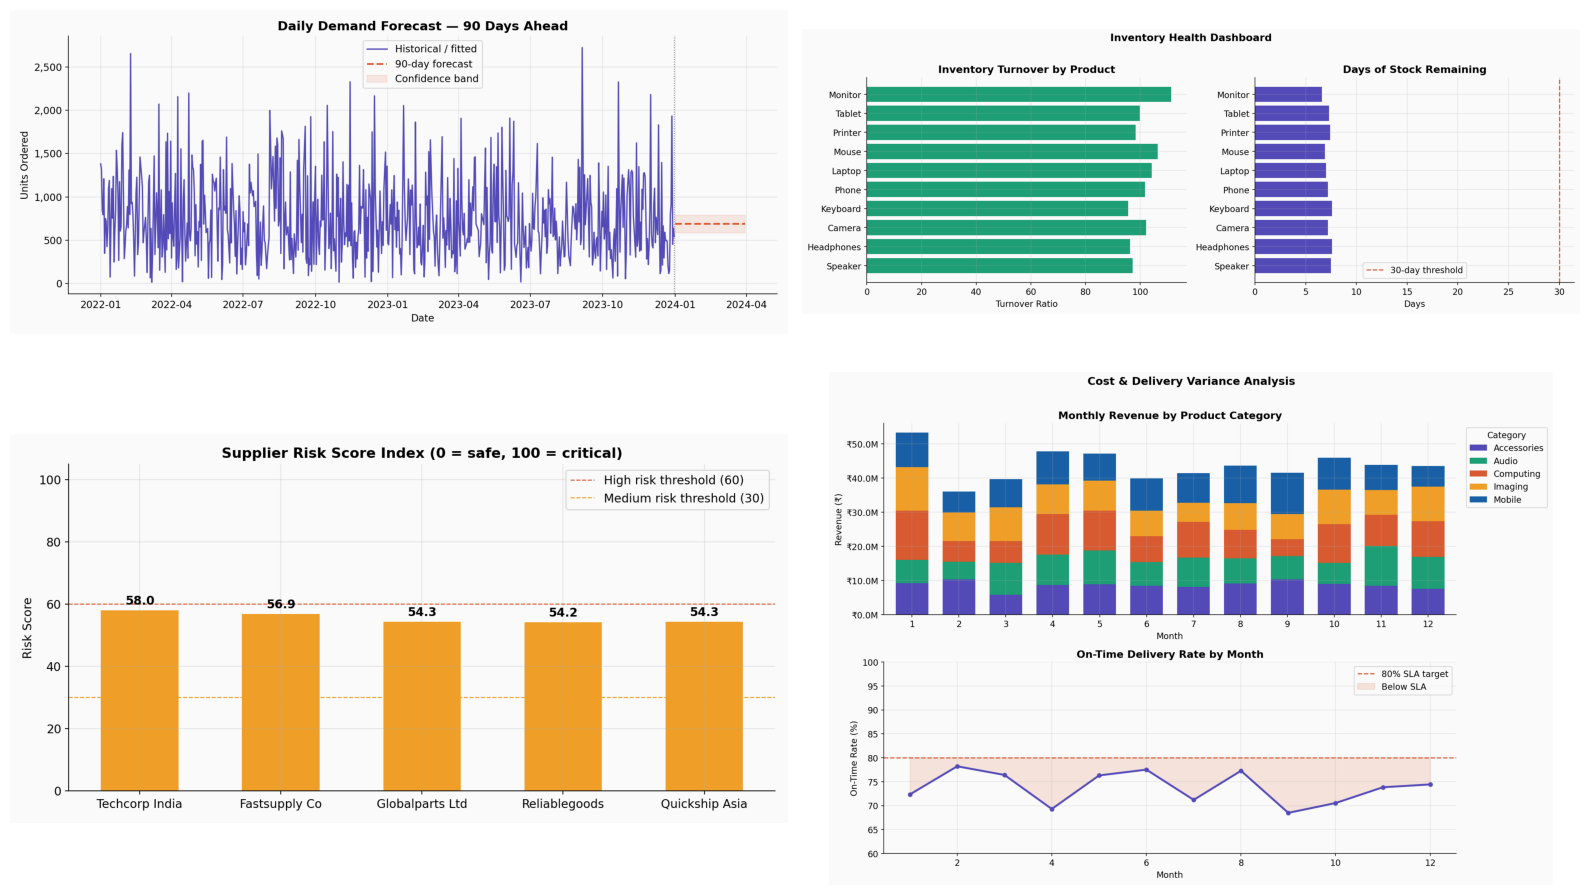

In [7]:
# Cell 5 — View charts inline
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
charts = ['chart_forecast','chart_inventory',
          'chart_supplier_risk','chart_cost_variance']

for ax, name in zip(axes.flatten(), charts):
    img = mpimg.imread(f'../data/outputs/{name}.png')
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()